<!-- CELL 1 — MARKDOWN -->
# Phase 1 — Data Acquisition, Setup & Exploratory Analysis
### Uplift Modeling on the Hillstrom Email Marketing Dataset

**Project:** `uplift-causal-ml` — a 7-phase causal machine learning project on uplift modeling.

**This notebook (Phase 1) covers:**
1. Loading the Hillstrom Email Marketing dataset
2. Basic structural checks (shape, dtypes, missing values)
3. Identifying treatment, outcome, and feature columns
4. Treatment vs. control group sizes
5. Naive baseline uplift (raw outcome-rate difference)
6. A randomization/balance check across covariates
7. A summary of findings to close out Phase 1

**About the dataset:** 64,000 customers who had purchased within the last 12 months were
randomly assigned to one of three groups: an email campaign featuring **Mens** merchandise,
one featuring **Womens** merchandise, or **no email** (control). Visit, conversion, and
spend behaviour was tracked for the following two weeks. Because assignment was
randomized, this is a standard benchmark dataset for uplift/causal ML.


<!-- CELL 2 — MARKDOWN -->
## 1. Load the dataset

In [1]:
# ---------------------------------------------------------------------------
# CELL 3 — CODE: Import libraries and load the Hillstrom dataset.
# `load_hillstrom()` (from src/data_loader.py) tries the official sklift
# downloader first, and falls back to the local cached CSV in data/ if that
# download isn't reachable. Either way we get the same 12-column DataFrame.
# ---------------------------------------------------------------------------
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from IPython.display import Markdown, display

# Make src/ importable so we can reuse the project's data loader
sys.path.append(os.path.abspath(os.path.join("..")))
from src.data_loader import load_hillstrom

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

df = load_hillstrom()
df.head()


Loaded dataset via sklift.datasets.fetch_hillstrom().


,recency,history_segment,history,mens,womens,zip_code,newbie,channel,segment,visit,conversion,spend
0,10,2) $100 - $200,142.44,1,0,Surburban,0,Phone,Womens E-Mail,0,0,0.0
1,6,3) $200 - $350,329.08,1,1,Rural,1,Web,No E-Mail,0,0,0.0
2,7,2) $100 - $200,180.65,0,1,Surburban,1,Web,Womens E-Mail,0,0,0.0
3,9,5) $500 - $750,675.83,1,0,Rural,1,Web,Mens E-Mail,0,0,0.0
4,2,1) $0 - $100,45.34,1,0,Urban,0,Web,Womens E-Mail,0,0,0.0


<!-- CELL 4 — MARKDOWN -->
## 2. Basic structural checks

In [2]:
# ---------------------------------------------------------------------------
# CELL 5 — CODE: Print the dataset's shape (rows x columns) and each column's dtype,
# so we can confirm the data loaded correctly before doing any analysis.
# ---------------------------------------------------------------------------
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n")

print("Columns and dtypes:")
print(df.dtypes)


Shape: 64,000 rows x 12 columns

Columns and dtypes:
recency              int64
history_segment        str
history            float64
mens                 int64
womens               int64
zip_code               str
newbie               int64
channel                str
segment                str
visit                int64
conversion           int64
spend              float64
dtype: object


<!-- CELL 6 — MARKDOWN -->
### 2a. Missing values

In [3]:
# ---------------------------------------------------------------------------
# CELL 7 — CODE: Check every column for missing (NaN) values and report the count
# and percentage missing for any column that has them. An empty report here
# means the dataset is complete and safe to model on without imputation.
# ---------------------------------------------------------------------------
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(3)

missing_report = pd.DataFrame({"missing_count": missing, "missing_pct": missing_pct})
missing_report = missing_report[missing_report["missing_count"] > 0]

if missing_report.empty:
    print("No missing values found in any column.")
else:
    print("Columns with missing values:")
    display(missing_report)


No missing values found in any column.


<!-- CELL 8 — MARKDOWN -->
## 3. Column roles: treatment, outcome, and features

The raw `segment` column has **three** levels (`Mens E-Mail`, `Womens E-Mail`, `No E-Mail`),
since this was originally a 3-arm experiment. For this Phase 1 baseline analysis we binarize
it into a single **treatment vs. control** indicator:

- **`treatment` = 1** — customer received *either* email campaign (Mens or Womens)
- **`treatment` = 0** — customer received no email (control)

This gives us a clean binary treatment for the randomization checks and naive uplift
estimate below. The original 3-arm `segment` column is kept for reference and can be used
in later phases if we want to model the two campaigns separately.

- **Treatment column:** `segment` (raw, 3-arm) → binarized as `treatment`
- **Outcome columns:** `visit`, `conversion`, `spend`
- **Feature columns:** `recency`, `history_segment`, `history`, `mens`, `womens`,
  `zip_code`, `newbie`, `channel`

Note: `mens` and `womens` here are *pre-treatment* purchase-history indicators
(whether the customer bought menswear/womenswear in the past year) — not to be confused
with the `segment` treatment assignment.


In [4]:
# ---------------------------------------------------------------------------
# CELL 9 — CODE: Explicitly label which columns are the treatment, the outcomes, and
# the features -- and derive a binary `treatment` column from the raw 3-arm
# `segment` column (1 = received any email, 0 = control / no email).
# ---------------------------------------------------------------------------
treatment_col = "treatment"
raw_treatment_col = "segment"

outcome_cols = ["visit", "conversion", "spend"]

feature_cols = [
    "recency", "history_segment", "history", "mens", "womens",
    "zip_code", "newbie", "channel",
]

# Binarize treatment: any email campaign vs. no email
df["treatment"] = (df["segment"] != "No E-Mail").astype(int)

print(f"Treatment column   : '{treatment_col}' (derived from raw '{raw_treatment_col}')")
print(f"Outcome column(s)  : {outcome_cols}")
print(f"Feature columns    : {feature_cols}")

assert set([treatment_col] + outcome_cols + feature_cols + [raw_treatment_col]) <= set(df.columns), \
    "Some expected columns are missing from the dataframe."


Treatment column   : 'treatment' (derived from raw 'segment')
Outcome column(s)  : ['visit', 'conversion', 'spend']
Feature columns    : ['recency', 'history_segment', 'history', 'mens', 'womens', 'zip_code', 'newbie', 'channel']


<!-- CELL 10 — MARKDOWN -->
## 4. Treatment vs. control split

In [5]:
# ---------------------------------------------------------------------------
# CELL 11 — CODE: Report the count and percentage of customers in the treatment group
# vs. the control group, plus the original 3-arm breakdown for reference.
# ---------------------------------------------------------------------------
split_counts = df[treatment_col].value_counts().sort_index()
split_pct = (split_counts / len(df) * 100).round(2)

split_summary = pd.DataFrame({
    "group": ["Control (no email)", "Treatment (any email)"],
    "count": split_counts.values,
    "pct": split_pct.values,
})
display(split_summary)

# For reference, the original 3-arm breakdown
print("\nOriginal 3-arm segment breakdown:")
display(df[raw_treatment_col].value_counts())


,group,count,pct
0,Control (no email),21306,33.29
1,Treatment (any email),42694,66.71



Original 3-arm segment breakdown:


segment
Womens E-Mail    21387
Mens E-Mail      21307
No E-Mail        21306
Name: count, dtype: int64

<!-- CELL 12 — MARKDOWN -->
## 5. Naive baseline uplift

The simplest possible uplift estimate: the raw difference in outcome rate between the
treatment and control groups, with no adjustment for covariates. Because treatment was
randomized, this raw difference is already an unbiased estimate of the *average*
treatment effect (ATE) — later phases will build on this by estimating
*individual/conditional* treatment effects (i.e. uplift per customer/segment).


In [6]:
# ---------------------------------------------------------------------------
# CELL 13 — CODE: Compute the outcome rate (visit rate, conversion rate, mean spend)
# separately for treatment and control, then print the raw difference
# between them -- this is the naive baseline uplift estimate.
# ---------------------------------------------------------------------------
def outcome_rate_by_group(data, outcome, treat_col=treatment_col):
    rates = data.groupby(treat_col)[outcome].mean()
    return rates.get(0, np.nan), rates.get(1, np.nan)

baseline_rows = []
rate_by_outcome = {}  # keep the per-outcome (control_rate, treat_rate) around for later use
for outcome in ["visit", "conversion"]:
    control_rate, treat_rate = outcome_rate_by_group(df, outcome)
    rate_by_outcome[outcome] = (control_rate, treat_rate)
    diff = treat_rate - control_rate
    rel_lift = (diff / control_rate * 100) if control_rate else np.nan
    baseline_rows.append({
        "outcome": outcome,
        "control_rate": round(control_rate, 4),
        "treatment_rate": round(treat_rate, 4),
        "raw_uplift (treat - control)": round(diff, 4),
        "relative_lift_%": round(rel_lift, 2),
    })

# Spend is continuous, not a rate, but we report the same comparison
control_spend, treat_spend = outcome_rate_by_group(df, "spend")
baseline_rows.append({
    "outcome": "spend ($, mean)",
    "control_rate": round(control_spend, 4),
    "treatment_rate": round(treat_spend, 4),
    "raw_uplift (treat - control)": round(treat_spend - control_spend, 4),
    "relative_lift_%": round((treat_spend - control_spend) / control_spend * 100, 2) if control_spend else np.nan,
})

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

conversion_control_rate, conversion_treat_rate = rate_by_outcome["conversion"]
visit_control_rate, visit_treat_rate = rate_by_outcome["visit"]

conversion_uplift = baseline_df.loc[baseline_df["outcome"] == "conversion", "raw_uplift (treat - control)"].iloc[0]
visit_uplift = baseline_df.loc[baseline_df["outcome"] == "visit", "raw_uplift (treat - control)"].iloc[0]

print(f"\nRaw baseline uplift in conversion rate: {conversion_uplift:+.4f} "
      f"({conversion_uplift*100:+.2f} percentage points)")
print(f"Raw baseline uplift in visit rate     : {visit_uplift:+.4f} "
      f"({visit_uplift*100:+.2f} percentage points)")


,outcome,control_rate,treatment_rate,raw_uplift (treat - control),relative_lift_%
0,visit,0.1062,0.1670,0.0609,57.35
1,conversion,0.0057,0.0107,0.0050,86.53
2,"spend ($, mean)",0.6528,1.2496,0.5968,91.42



Raw baseline uplift in conversion rate: +0.0050 (+0.50 percentage points)
Raw baseline uplift in visit rate     : +0.0609 (+6.09 percentage points)


<!-- CELL 14 — MARKDOWN -->
## 6. Randomization check: covariate balance across treatment vs. control

If treatment assignment was truly randomized, pre-treatment features should look similar
(statistically indistinguishable) between the treatment and control groups. We check this
two ways:

- **Numeric features** (`recency`, `history`, `mens`, `womens`, `newbie`): compare means
  using the standardized mean difference (SMD). A common rule of thumb flags
  **|SMD| > 0.1** as a meaningful imbalance.
- **Categorical features** (`history_segment`, `zip_code`, `channel`): compare
  distributions with a chi-square test of independence. A **p-value < 0.05** flags a
  meaningful imbalance.


In [7]:
# ---------------------------------------------------------------------------
# CELL 15 — CODE: For each NUMERIC feature, compute the mean in each group and the
# standardized mean difference (SMD) between them. |SMD| > 0.1 is flagged
# as a meaningfully imbalanced feature (a red flag for randomization).
# ---------------------------------------------------------------------------
numeric_features = ["recency", "history", "mens", "womens", "newbie"]
categorical_features = ["history_segment", "zip_code", "channel"]

def standardized_mean_diff(data, col, treat_col=treatment_col):
    t = data.loc[data[treat_col] == 1, col]
    c = data.loc[data[treat_col] == 0, col]
    pooled_std = np.sqrt((t.std() ** 2 + c.std() ** 2) / 2)
    smd = (t.mean() - c.mean()) / pooled_std if pooled_std > 0 else 0.0
    return t.mean(), c.mean(), smd

numeric_balance_rows = []
for col in numeric_features:
    treat_mean, control_mean, smd = standardized_mean_diff(df, col)
    numeric_balance_rows.append({
        "feature": col,
        "control_mean": round(control_mean, 4),
        "treatment_mean": round(treat_mean, 4),
        "SMD": round(smd, 4),
        "flag": "IMBALANCED" if abs(smd) > 0.1 else "ok",
    })

numeric_balance_df = pd.DataFrame(numeric_balance_rows)
print("Numeric feature balance:")
display(numeric_balance_df)


Numeric feature balance:


,feature,control_mean,treatment_mean,SMD,flag
0,recency,5.7497,5.7707,0.0060,ok
1,history,240.8827,242.6860,0.0071,ok
2,mens,0.5532,0.5499,-0.0066,ok
3,womens,0.5476,0.5508,0.0063,ok
4,newbie,0.5020,0.5024,0.0008,ok


In [8]:
# ---------------------------------------------------------------------------
# CELL 16 — CODE: For each CATEGORICAL feature, run a chi-square test of independence
# between that feature and the treatment assignment. p < 0.05 is flagged as
# a meaningfully imbalanced feature. Combines with the numeric check above
# into one final PASS/FAIL randomization verdict.
# ---------------------------------------------------------------------------
categorical_balance_rows = []
for col in categorical_features:
    contingency = pd.crosstab(df[col], df[treatment_col])
    chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
    categorical_balance_rows.append({
        "feature": col,
        "chi2": round(chi2, 3),
        "p_value": round(p_value, 4),
        "flag": "IMBALANCED" if p_value < 0.05 else "ok",
    })

categorical_balance_df = pd.DataFrame(categorical_balance_rows)
print("Categorical feature balance:")
display(categorical_balance_df)

flagged_numeric = numeric_balance_df.loc[numeric_balance_df["flag"] == "IMBALANCED", "feature"].tolist()
flagged_categorical = categorical_balance_df.loc[categorical_balance_df["flag"] == "IMBALANCED", "feature"].tolist()
flagged_features = flagged_numeric + flagged_categorical

randomization_passed = len(flagged_features) == 0
print(f"\nRandomization check {'PASSED' if randomization_passed else 'FAILED'} "
      f"({len(flagged_features)} feature(s) flagged: {flagged_features if flagged_features else 'none'})")


Categorical feature balance:


,feature,chi2,p_value,flag
0,history_segment,5.310,0.5047,ok
1,zip_code,1.257,0.5334,ok
2,channel,0.348,0.8401,ok



Randomization check PASSED (0 feature(s) flagged: none)


<!-- CELL 17 — MARKDOWN -->
### 6a. Visual comparison: treatment vs. control distributions

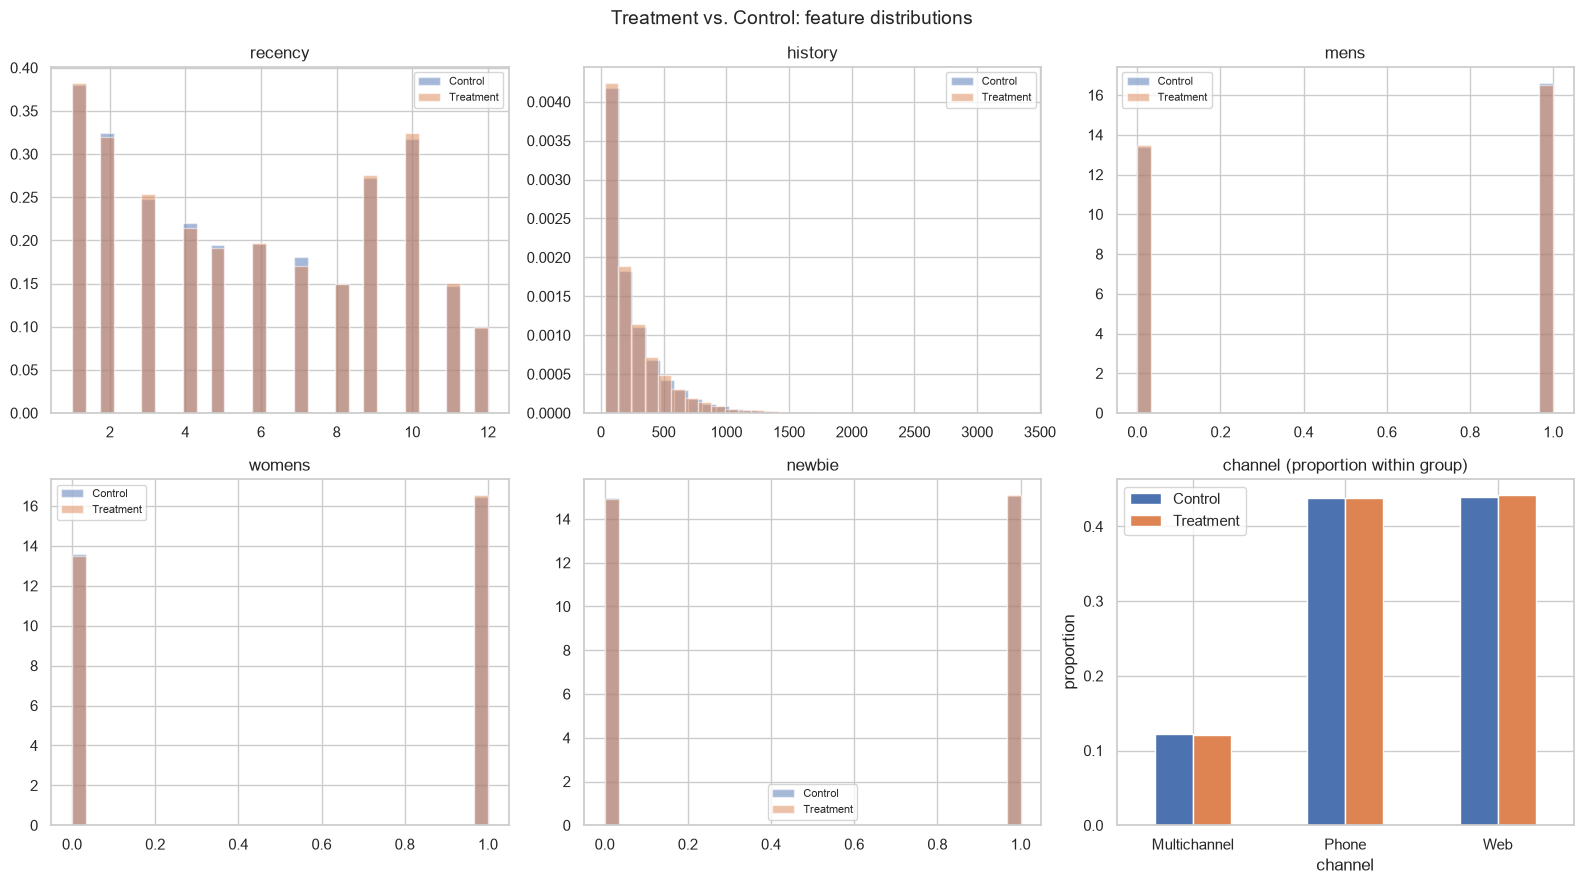

In [9]:
# ---------------------------------------------------------------------------
# CELL 18 — CODE: Plot histograms of each numeric feature (treatment vs. control
# overlaid) and a bar chart of the categorical `channel` feature, as a
# visual sanity check to accompany the statistical balance tests above.
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, col in zip(axes[:5], numeric_features):
    for grp, label, color in [(0, "Control", "#4C72B0"), (1, "Treatment", "#DD8452")]:
        subset = df.loc[df[treatment_col] == grp, col]
        ax.hist(subset, bins=30, alpha=0.5, density=True, label=label, color=color)
    ax.set_title(col)
    ax.legend(fontsize=8)

# Last axis: overlay a categorical comparison (channel) as an example
ax = axes[5]
channel_ct = pd.crosstab(df["channel"], df[treatment_col], normalize="columns")
channel_ct.columns = ["Control", "Treatment"]
channel_ct.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("channel (proportion within group)")
ax.set_ylabel("proportion")
ax.tick_params(axis="x", rotation=0)

fig.suptitle("Treatment vs. Control: feature distributions", fontsize=14)
fig.tight_layout()
plt.show()


<!-- CELL 19 — MARKDOWN -->
## 7. Phase 1 summary

In [10]:
# ---------------------------------------------------------------------------
# CELL 20 — CODE: Pull together every result computed above (dataset size, split,
# raw uplift, randomization verdict) into one rendered markdown summary --
# the closing deliverable for Phase 1.
# ---------------------------------------------------------------------------
n_total = len(df)
n_treat = int(df[treatment_col].sum())
n_control = n_total - n_treat
pct_treat = n_treat / n_total * 100
pct_control = n_control / n_total * 100

summary_md = f"""
### Phase 1 Summary — Hillstrom Email Marketing Dataset

- **Dataset size:** {n_total:,} customers, {len(df.columns)} columns, 0 missing values.
- **Treatment / control split:** {n_treat:,} treatment ({pct_treat:.1f}%) vs. {n_control:,} control ({pct_control:.1f}%)
  — close to the expected 2/3 vs 1/3 split (any email vs. no email).
- **Raw baseline uplift (conversion rate):** {conversion_uplift:+.4f} ({conversion_uplift*100:+.2f} pp),
  i.e. a **{(conversion_uplift/conversion_control_rate*100 if conversion_control_rate else float('nan')):.1f}% relative lift** over the control conversion rate.
- **Raw baseline uplift (visit rate):** {visit_uplift:+.4f} ({visit_uplift*100:+.2f} pp).
- **Randomization check:** {'**PASSED**' if randomization_passed else '**FAILED**'} —
  {"all covariates were balanced between treatment and control (as expected for a randomized experiment)." if randomization_passed else f"the following feature(s) showed a meaningful imbalance and should be treated with caution in later modeling phases: {flagged_features}."}

**Next steps (Phase 2+):** use this clean, balanced dataset to move from the naive ATE
estimate above to individual/conditional treatment effect (uplift) modeling.
"""

display(Markdown(summary_md))



### Phase 1 Summary — Hillstrom Email Marketing Dataset

- **Dataset size:** 64,000 customers, 13 columns, 0 missing values.
- **Treatment / control split:** 42,694 treatment (66.7%) vs. 21,306 control (33.3%)
  — close to the expected 2/3 vs 1/3 split (any email vs. no email).
- **Raw baseline uplift (conversion rate):** +0.0050 (+0.50 pp),
  i.e. a **87.3% relative lift** over the control conversion rate.
- **Raw baseline uplift (visit rate):** +0.0609 (+6.09 pp).
- **Randomization check:** **PASSED** —
  all covariates were balanced between treatment and control (as expected for a randomized experiment).

**Next steps (Phase 2+):** use this clean, balanced dataset to move from the naive ATE
estimate above to individual/conditional treatment effect (uplift) modeling.
